# Ders 1 — Derin Öğrenme vs Makine Öğrenmesi ve Tensor Kavramı

**Program:** Python ile Derin Öğrenme Tabanlı Görüntü ve Doğal Dil İşleme
**Modül 1 · Oturum 1** · Önerilen süre: 4 saat

## Bu oturumun hedefleri
1. Makine öğrenmesi ile derin öğrenme arasındaki farkı **tek cümleyle** açıklayabilmek
2. Derin öğrenmenin neden bugün baskın olduğunu (veri, donanım, öznitelik) tartışabilmek
3. **Tensor** kavramını tanımlamak: skaler → vektör → matris → tensor
4. PyTorch'ta tensor üretmek, `shape` / `dtype` / `ndim` okumak
5. Bir renkli görüntünün gerçekte bir tensor olduğunu **kendi kodunla** doğrulamak


## 0 · Giriş: Makine Öğrenmesi ve Derin Öğrenme Nedir, Farkları Nelerdir?

**Makine öğrenmesi (ML)**: Bilgisayara kural yazmak yerine **veriden kural çıkarmaktır**.
Klasik ML'de insan ham veriyi önce **özniteliklere (feature)** çevirir — örn. bir e-postayı
spam yapacak şeylerin (para geçen kelimeler, gönderi sayısı...) listesini insan seçer —
sonra basit bir model (doğrusal regresyon, ağaç, SVM) bu özniteliklerden karar cikarmayi öğrenir.

**Derin öğrenme (DL)**: ML'nin, modelin **çok katmanlı sinir ağı** olduğu özel halidir.
İnsan ham veriyi (pikseller, ses dalgaları, ham metin) olduğu gibi verir; ağın katmanları
**öznitelikleri de kendileri öğrenir**: ilk katmanlar kenar/harf gibi basit desenleri,
sonraki katmanlar yüz/anlam gibi kavramları birleştirir.

| | Klasik ML | Derin öğrenme |
|---|---|---|
| Öznitelik kimi seçer? | **İnsan** | **Ağ (katmanlar)** |
| Ham veriyle çalışır mı? | Genellikle hayır | Evet (piksel/ses/metin) |
| Küçük veride | Çok iyi, hızlı | Kolayca ezberler (aşırı öğrenme) |
| Büyük veride | Yatak kalır | Veri arttıkça iyileşir |
| Donanım ihtiyacı | Az | GPU ister |
| Örnek | Ev fiyatı tahmini (tablo) | Görüntü tanıma, çeviri |

**Tek cümlelik fark:** klasik ML'de *öğrenme ile öznitelik çıkarma* işi insanın; DL'de
ikisi de ağa verilir. Aşağıdaki mini demo bunu 10 satırda kanıtlar.

### Arka plandaki matematik

İkisi de aynı görevi yapar: $y = f(x)$ fonksiyonunu veriden öğrenmek. Fark, $f$'nin ne
olduğunda:
- **Klasik ML:** $f(x) = w \cdot \phi(x) + b$ — $\phi$ (öznitelik dönüşümü) **insan eliyle sabit**; model yalnızca $w$'yi öğrenir.
- **DL:** $f(x) = f_L(\cdots f_2(f_1(x)))$ — her katman bir öncekinin çıktısını yeniden dönüştürür; $\phi$'nın karşılığı **ağın içinde öğrenilir**.

Bir sinir ağının "derin"liği, bu $f_1 \dots f_L$ zincirinin katman sayısıdır.

A · doğrusal + ham koordinat (klasik ML, özniteliksiz) : doğruluk 56%
B · doğrusal + insan özniteliği (klasik ML, özniteliği): doğruluk 100%
C · MLP + ham koordinat (derin öğrenme)                : doğruluk 100%


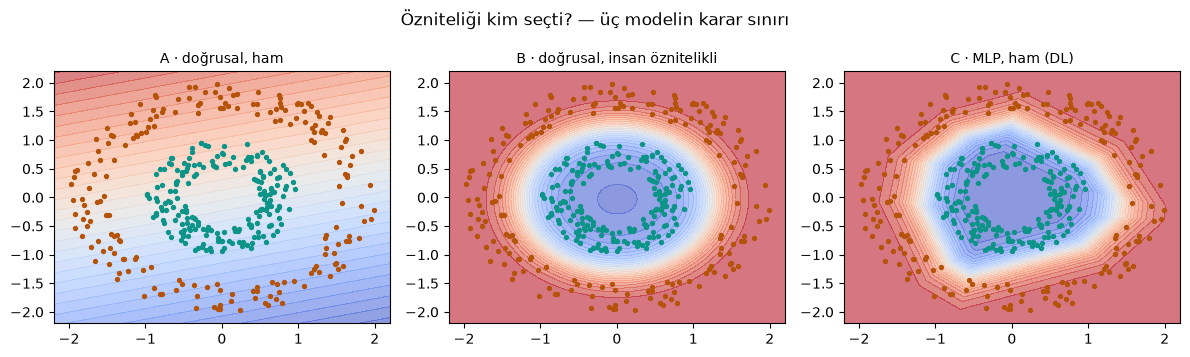

In [11]:
# Bu demo, bölüm 1'in tezini tek tabloda kanıtlar: ham veride (x1, x2)
# klasik-doğrusal model başarısız olur; insan öznitelik ekleyince kurtulur;
# derin ağ özniteliği kendi bulur — üçü aynı veriyle yarışır.
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# tekrarlanabilirlik: veri ve ağırlıklar her koşuda aynı.
torch.manual_seed(42); np.random.seed(42)

# veri: içteki halka = sınıf 0, dış halka = sınıf 1 (ders 1'in halka problemiyle aynı fikir).
n = 200
# iç halka: yarıçapı 0.5-1.0 arası 200 nokta.
r1 = np.random.uniform(0.5, 1.0, n); 
a1 = np.random.uniform(0, 2*np.pi, n)

# dış halka: yarıçapı 1.5-2.0 arası 200 nokta.
r2 = np.random.uniform(1.5, 2.0, n); 
a2 = np.random.uniform(0, 2*np.pi, n)

# girdi matrisi (400, 2): ham koordinatlar; hedef (400, 1): 0 = iç halka, 1 = dış halka.
X = np.vstack([np.c_[r1*np.cos(a1), r1*np.sin(a1)], 
               np.c_[r2*np.cos(a2), r2*np.sin(a2)]]).astype(np.float32)

Y = np.r_[np.zeros(n), np.ones(n)].astype(np.float32).reshape(-1, 1)

X_t, Y_t = torch.tensor(X), torch.tensor(Y)

# model A — klasik ML'nin "insan öznitelik eklemedi" hali: düz doğrusal sınıflandırıcı.
# Doğrusal model halkayı bir doğruyla ayıramaz: dairesel sınırı asla çizemez.
lin = nn.Linear(2, 1)

# model B — insan öznitelik ekledi: ham koordinat yerine yarıçap ~sqrt(x1²+x2²)
# sütununu elle hesaplayıp tek nörona veriyor (klasik ML'nin doğal hali).
feat = torch.tensor(np.c_[X, X[:, 0]**2 + X[:, 1]**2], dtype=torch.float32)  # 3. sütun = yarıçapın karesi
lin_feat = nn.Linear(3, 1)

# model C — derin öğrenme: ham (x1, x2) verisi + 2 gizli katman; özniteliği
# (dairesel sınırı) kendisi öğrenir. İnsan hiçbir şey eklemez.
mlp = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1))

# ortak eğitim fonksiyonu: aynı veri, aynı adım sayısı — adil kıyas.
def egit(model, girdi, adim=400, lr=0.1):
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    for _ in range(adim):
        opt.zero_grad()
        predict = model(girdi)
        kayip = nn.BCEWithLogitsLoss()(predict, Y_t)  # ikili sınıflandırma kaybı
        kayip.backward(); 
        opt.step()
    with torch.no_grad():
        dogru = ((torch.sigmoid(model(girdi)) > 0.5) == (Y_t > 0.5)).float().mean().item()
    return dogru

# üç modeli aynı veriyle eğitir ve doğrulukları yazar.
acc_a = egit(lin, X_t)                  # ham koordinat + doğrusal
acc_b = egit(lin_feat, feat)            # insan özniteliği + doğrusal
acc_c = egit(mlp, X_t, adim=1500, lr=0.05)         # ham koordinat + MLP (DL)
print(f"A · doğrusal + ham koordinat (klasik ML, özniteliksiz) : doğruluk {acc_a:.0%}")
print(f"B · doğrusal + insan özniteliği (klasik ML, özniteliği): doğruluk {acc_b:.0%}")
print(f"C · MLP + ham koordinat (derin öğrenme)                : doğruluk {acc_c:.0%}")

# karar sınırlarını yan yana çizer: fark gözle görülür hale gelir.
xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 200), np.linspace(-2.2, 2.2, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()].astype(np.float32))
plt.figure(figsize=(12, 3.6))
for j, (ad, mdl, grs) in enumerate([("A · doğrusal, ham", lin, grid),
                                    ("B · doğrusal, insan öznitelikli", None, None),
                                    ("C · MLP, ham (DL)", mlp, grid)]):
    plt.subplot(1, 3, j + 1)
    if ad.startswith("B"):
        # B'nin sınırı: yarıçap karesi ~ eşik — daire çizer; analitik çiziyoruz.
        rr = xx**2 + yy**2
        with torch.no_grad():
            zz = torch.sigmoid(lin_feat(torch.tensor(np.c_[xx.ravel(), yy.ravel(), rr.ravel()], dtype=torch.float32)))
    else:
        with torch.no_grad():
            zz = torch.sigmoid(mdl(grs))
    plt.contourf(xx, yy, zz.reshape(xx.shape), levels=30, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:n, 0], X[:n, 1], s=8, c="#0d9488", label="sınıf 0 (iç)")
    plt.scatter(X[n:, 0], X[n:, 1], s=8, c="#b45309", label="sınıf 1 (dış)")
    plt.title(ad, fontsize=10); plt.xlim(-2.2, 2.2); plt.ylim(-2.2, 2.2)
plt.suptitle("Özniteliği kim seçti? — üç modelin karar sınırı")
plt.tight_layout(); plt.show()

# Sonuç: A duvara toslar, B insana muhtaç, C özniteliği öğrenerek kazanır —
# bu dersin geri kalanında eğiteceğimiz tam olarak bu 'öğrenme' makinesidir.


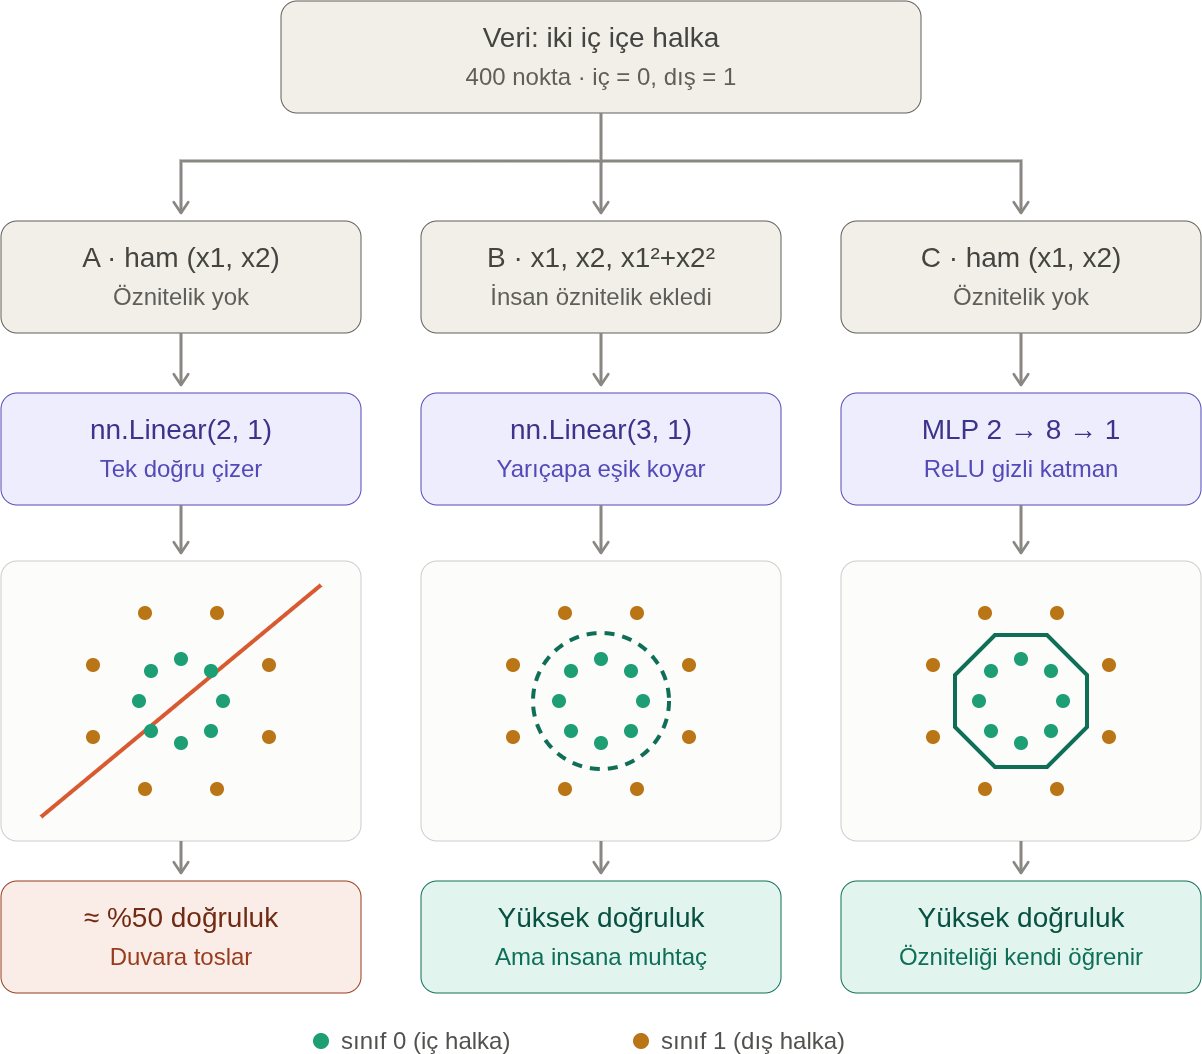  

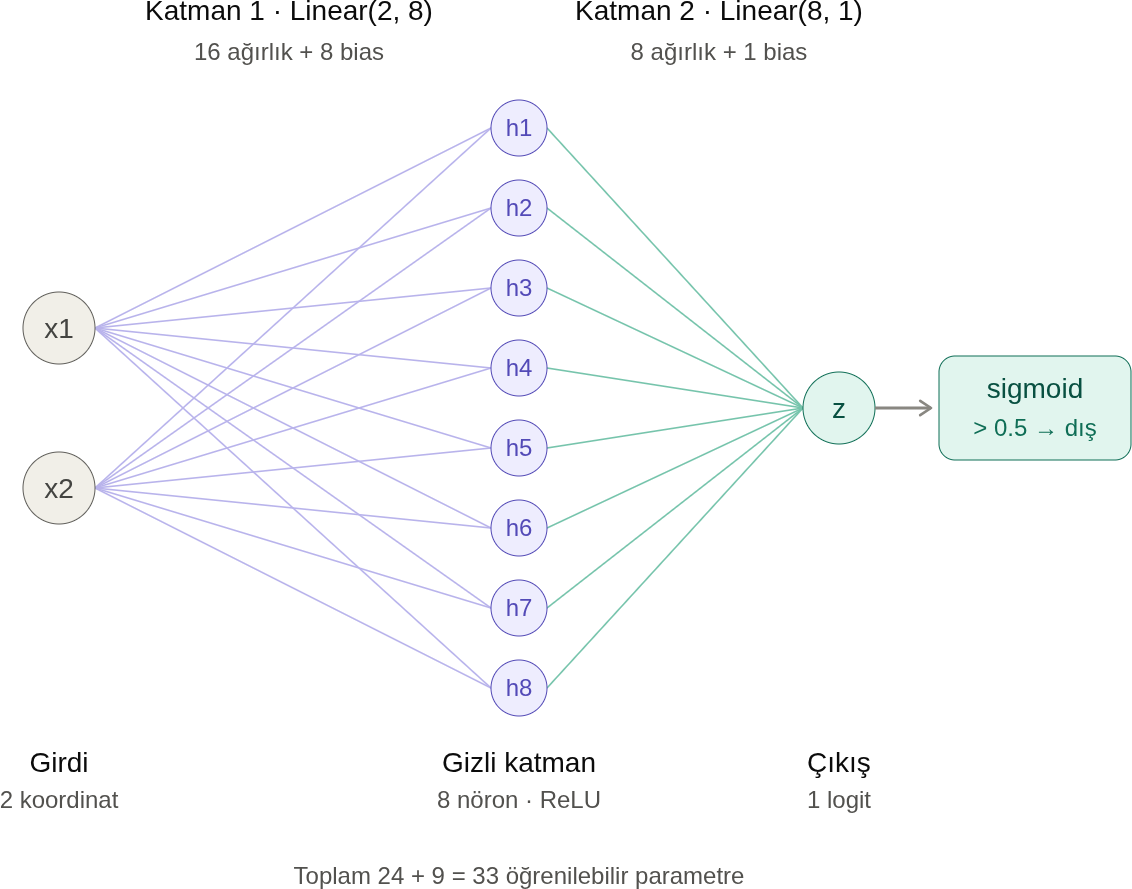

## 1 · Makine Öğrenmesi vs Derin Öğrenme

İkisi de **veriden fonksiyon öğrenir**. Fark, işin en zahmetli adımının kime ait olduğunda:

| | **Klasik ML** | **Derin Öğrenme** |
|---|---|---|
| Öznitelik (feature) | **İnsan** tasarlar | **Ağ** ham veriden öğrenir |
| Veri | Az veriyle çalışır | Çok veriyle parlaklığa çıkar |
| Donanım | CPU genelde yeter | GPU büyük avantaj |
| Tipik örnek | TF-IDF + Lojistik Regresyon | CNN, RNN, Transformer |

> **Ne zaman klasik ML?** Tablo verisi, küçük veri, yorumlanabilirlik şart olduğunda.
> Bu dersin odağı: ham **görüntü** ve **metin** → derin öğrenme alanına girer.

### Arka plandaki matematik

Her iki yaklaşım da veriden bir fonksiyon öğrenir: $y = f(x)$. Fark, $f$'in nasıl kurulduğundadır:

- **Klasik ML:** $\;y = f(\phi(x))\;$ — önce insan, $\phi$ ile öznitelik çıkarımını elle yazar (ör. kelime sayıları, ortalama piksel), sonra basit bir $f$ öğrenilir.
- **Derin öğrenme:** $\;y = f_K(f_{K-1}(\dots f_1(x)))\;$ — öznitelik de dahil her şey katman katman öğrenilir.

Mini sayısal örnek: 100 kelimelik bir e-postayı sınıflandıracak klasik ML'e $x = (\text{spam kelime sayısı}, \text{uzunluk}, \text{bağlantı adedi})$ gibi 3 özniteliği elle verirsin; derin model aynı metnin 100 ham sayısından başlar ve kendisi hangi bileşimlerin işe yaradığını öğrenir. Öğrenilecek parametre sayısı ikincide yüz binlerle başlar — bu yüzden çok veriye ihtiyaç duyar.

> Bu blok, klip 1.1'deki "boru hattı farkı" animasyonunun arkasındaki tek satırlık matematiği verir: öznitelik adımının insandan ağa taşınması, sonraki tüm oturumların temel fikridir.

In [2]:
# IPython'un görüntüleme araçlarını içe aktarır; `Video` sınıfı MP4 klibi
# hücre çıktısı olarak göstermek için gereklidir. Neden: ders klibini
# notebook içinde oynatmak. Yarar: ayrı oynatıcı açmadan içerik tek
# dosyada kalır.
from IPython.display import Video

# 1.1 — Klasik ML ile derin öğrenmenin boru hattı farkı
# MP4 klibini hücre çıktısı olarak gösterir; kavramı metinden daha hızlı
# anlatır. `embed=True` videoyu notebook dosyasına gömer: dosya yolu veya
# internet olmadan da oynar. `width=1000` görüntü genişliğini piksel
# cinsinden belirler.
Video("assets/01-dl-vs-ml.mp4", width=1000, embed=True)

### Neden derin öğrenme? Üç itici güç

1. **Büyük veri** — İnternet çağı milyonlarca etiketli örnek üretti; klasik yöntemler belirli bir veri miktarından sonra platoya oturur, derin ağlar büyümeye devam eder.
2. **GPU donanımı** — Derin ağ = katman katman **matris çarpımı**. GPU bu işlemleri binlerce çekirdekle paralel yapar; 2012'den beri derin öğrenmenin yakıtı budur.
3. **Otomatik öznitelik** — Elle özellik mühendisliği (kenar mı, doku mu, SIFT mi?) yerine ağ **temsili kendi öğrenir**. Görüntü ve dilde "doğru öznitelik"i elle tasarlamak neredeyse imkânsızdı.

> Küçük veri + tablo problemi → klasik ML hâlâ mantıklı seçim. Derin öğrenme, veri ve hesap gücüyle beslenir.

### Arka plandaki matematik

"Derin öğrenme neden bugün baskın?" sorusunun sayısal cevabı veri–performans eğrisinde gizli: deneyimler, test hatasının veri miktarıyla **kuvvet yasası** gibi düştüğünü gösteriyor:

$$E(D) \approx E_\infty + c \cdot D^{-\alpha}$$

$D$ (Data / Veri Miktarı): Eğitmek için modele verdiğin toplam veri sayısı (örneğin 1.000 fotoğraf, 100.000 metin vb.).  
$E(D)$ (Error / Hata Miktarı): Modelin $D$ kadar veriyle eğitildikten sonra test setinde yaptığı hata oranı. Veri arttıkça bu değerin düşmesini isteriz.  
$E_\infty$ (Teorik Limit / Alt Sınır Hata): Veri miktarını sonsuza çıkarsan bile ($D \to \infty$) modelin yapmaya devam edeceği kaçınılmaz hata.Neden sıfır değil? Çünkü gerçek dünyadaki veride her zaman gürültü (noise), etiketi yanlış basılmış örnekler veya ölçüm hataları vardır. Buna Bayes Hatası da denir.  
$c$ (Ölçek Katsayısı): Problemin zorluğuna ve veri tipine göre değişen sabit bir sayı.$\alpha$ (Öğrenme Hızı / Scaling Exponent): Verinin hatayı ne kadar hızlı düşürdüğünü belirleyen en kritik güç göstergesi. Genellikle $0.3$ ile $0.5$ arasında değişir.

Mini sayısal örnek: $\alpha = 0{,}5$ için veriyi 4 katına çıkarınca hata yaklaşık yarıya iner ($D^{-0{,}5}$, $D=4$ için $1/2$). Klasik yöntemler belirli bir $D$'den sonra platoya oturur ($E_\infty$ yüksek kalır); derin ağlar platoya daha derinde oturur — ama bunu ancak büyük $D$ ve GPU ile görebilirsin.


> Bu blok, klip 1.2'deki eğrinin arkasındaki idealize formülü verir: "neden derin öğrenme" tartışmasını el sıkışabilir bir eğriye bağlar.

In [3]:
# 1.2 — Neden derin öğrenme? (veri–performans eğrisi)
# İkinci ders klibini notebook içine gömer (`embed=True`). Neden: veri–
# performans ilişkisini animasyonla göstermek. Yarar: grafik okumadan
# önce sezgi kurar.
Video("assets/02-neden-dl.mp4", width=1000, embed=True)

### Mini demo: "derin" ağ neden daha güçlü?

Aşağıdaki veri bir **halka problem**: içteki noktalar sınıf 0, dıştaki sınıf 1.
İki sınıfı **düz bir çizgiyle** ayırmak imkânsız — eğri bir sınıra ihtiyaç var.

- **Lineer model** (1 katman): sadece düz sınır çizebilir.
- **Derin model** (gizli katmanlar + aktivasyon): sınırı veriden öğrenir.

> Gradyan inişinin matematiği gelecek oturumda. Şimdilik eğitimi bir "sihirli kutu" olarak izle: **loss** (kayıp) değeri düştükçe model öğreniyor demektir.

### Arka plandaki matematik

Bu hücre üç matematik parçasını birden kullanır:

1. **Vektör normu** (uzunluk): $\;\|v\|_2 = \sqrt{v_1^2 + v_2^2}\;$. Kod, rastgele yönleri birim uzunluğa çekiyor: $v = (3, 4) \Rightarrow \|v\|_2 = \sqrt{9+16} = 5$, normalize edilmiş hâli $(0{,}6;\ 0{,}8)$. Norm ile bölerek halkanın dış halkasını eşit uzunlukta yönlerle örüyorsun.
2. **Sigmoid + ikili çapraz entropi**: model ham skor $z$ üretir; olasılık $\sigma(z) = \frac{1}{1+e^{-z}}$; kayıp $\mathcal{L} = -[\,t\log\sigma(z) + (1-t)\log(1-\sigma(z))\,]$. Sayısal örnek: $z = 1{,}0$, doğru etiket $t=1 \Rightarrow \sigma(1) \approx 0{,}73 \Rightarrow \mathcal{L} = -\log(0{,}73) \approx 0{,}31$. Tahmin doğruyorsa kayıp küçülür.
3. **Aktivasyon olarak tanh**: $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$, çıktı aralığı $(-1, 1)$. Katmanlar arasına konunca düz doğrular bükülür; iki gizli katman, halkayı saran eğri sınırı kurabilir.

> Bu blok için gerekli: "derin model neden daha güçlü" iddiasını **sayıyla kanıtlamak** — aynı veriye lineer ve derin modeli koşturup son kayıpları ve karar sınırlarını karşılaştırır. Gradyan inişinin kendisi bir sonraki oturumda; burada sadece motorun çalıştığını görüyoruz.

Lineer model son loss : 0.680
Derin model son loss  : 0.000


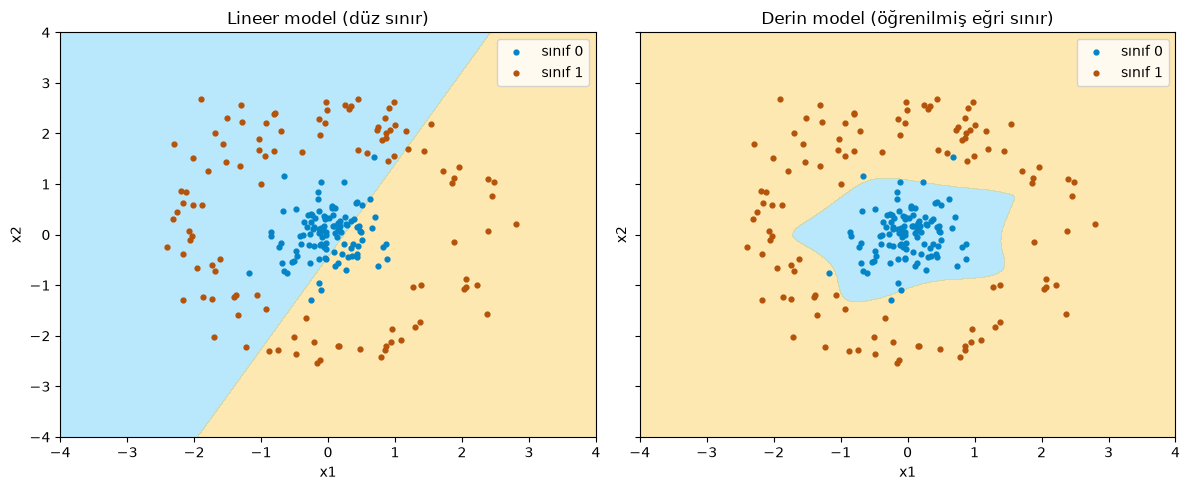

In [4]:
# torch: tensor kütüphanesi; torch.nn.functional (F): kayıp fonksiyonları
# modülü; matplotlib.pyplot: grafik kütüphanesi. Neden: veri üretimi,
# eğitim ve çizim için; üçü de oturumun geri kalanında kullanılacak.
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Rastgelelik tohumunu sabitler; her çalıştırmada aynı veri ve aynı sonuç
# için. Yarar: notebook tekrarlanabilir olur.
torch.manual_seed(0)
# İç ve dış sınıfın nokta sayıları (her sınıf 110 nokta).
n_in, n_out = 110, 110
# Merkeze yığılmış 110 nokta üretir (standart sapma 0,45 ile
# sıkıştırılmış). Neden: iç sınıfın halkanın içinde kalması için.
# Yarar: sınıf 0 verisini kurar.
inner = torch.randn(n_in, 2) * 0.45
# 110 rastgele 2B yön vektörü; dış halka noktalarının yönlerini seçmek için.
dir_ = torch.randn(n_out, 2)
# Her satırı kendi normuna bölerek birim vektör yapar. Neden: tüm yönler
# eşit uzunlukta olsun. Yarar: dış halka düzgün bir çember gibi dağılır;
# `keepdim=True` shape'i koruyarak satır-satır bölmeyi mümkün kılar.
dir_ = dir_ / dir_.norm(dim=1, keepdim=True)
# Birim yönleri 2,2 çevresinde rastgele yarıçaplarla ölçekler. Neden: dış
# sınıfı yarıçap ≈ 2,2 halkasına yaymak. Yarar: sınıf 1 verisini kurar.
outer = dir_ * (2.2 + 0.35 * torch.randn(n_out, 1))
# İki sınıfın noktalarını tek [220, 2] tensörde birleştirir. Neden: model
# tek giriş tensörü bekler. Yarar: eğitim verisi hazır.
X = torch.cat([inner, outer])
# Etiketleri üretir: ilk 110 satır 0, kalan 110 satır 1. Neden: kayıp
# fonksiyonu doğru etikete ihtiyaç duyar. Yarar: denetimli eğitim için
# hedef vektör.
y = torch.cat([torch.zeros(n_in, 1), torch.ones(n_out, 1)])

# Eğitim döngüsünü fonksiyona sarar. Neden: aynı döngüyü iki modelde
# tekrar kullanmak. Yarar: kod tekrarı olmaz.
def train(model, steps=800):
    # Adam optimizasyon algoritmasını kurar: gradyanlara göre parametre
    # güncelleyen akıllı adım atıcı. `lr=0,05` adım büyüklüğünü belirler.
    opt = torch.optim.Adam(model.parameters(), lr=0.05)
    for _ in range(steps):
        # Önceki adımın gradyanlarını sıfırlar; PyTorch gradyanları biriktirir,
        # sıfırlanmazsa adımlar karışır.
        opt.zero_grad()
        # İleri geçiş + ikili kayıp: modelin ham skorlarını (z) sigmoid + çapraz
        # entropiyle ortalama kayba çevirir. "Ne kadar yanlışız" sayısı lazım;
        # kayıp düşük = sınır iyi.
        loss = F.binary_cross_entropy_with_logits(model(X), y)
        # Kaybın tüm parametrelere göre türevini (gradyan) otomatik hesaplar;
        # elle türev yazmak zorunda kalmayız.
        loss.backward()
        # Gradyanlara bakarak parametreleri bir adım günceller; kaybı azaltmak
        # için. 800 adımda model öğrenir.
        opt.step()
    # Son kaybı Python sayısına çevirip döndürür; tensör yerine okunabilir
    # sayı, print ile karşılaştırma kolaylaşır.
    return loss.item()

# Tek doğrusal katman: y = w1*x1 + w2*x2 + b. Neden: "düz çizgi sınırı"
# iddiasını test etmek. Yarar: karşılaştırmanın temsili.
linear_model = torch.nn.Sequential(torch.nn.Linear(2, 1))
# İki gizli katmanlı ağ. Neden: doğrusal olmayan (bükülebilir) sınır için
# aktivasyon şart. Yarar: halkayı saran sınırı öğrenebilir.
deep_model = torch.nn.Sequential(
    torch.nn.Linear(2, 16), torch.nn.Tanh(),
    torch.nn.Linear(16, 16), torch.nn.Tanh(),
    torch.nn.Linear(16, 1),
)
# İki modeli de 800 adım eğitir ve son kayıpları alır; "derin daha iyi"
# iddiasının sayısal kanıtı.
loss_lin = train(linear_model)
loss_deep = train(deep_model)
# Sonuçları ekrana basar; kayıp farkını hemen görürsün.
print(f"Lineer model son loss : {loss_lin:.3f}")
print(f"Derin model son loss  : {loss_deep:.3f}")

# -4 ile 4 arasında 200 eşit aralıklı nokta; karar sınırını çizmek için
# bir ızgara lazım.
xx = torch.linspace(-4, 4, 200)
# İki ekseni birleştirip 200 × 200 koordinat ızgarası kurar. Neden:
# düzlemdeki her noktanın model tahminine ihtiyaç var. Yarar: ısı
# haritası çizilebilir.
gx, gy = torch.meshgrid(xx, xx, indexing="ij")
# Izgarayı [40000, 2] nokta listesine düzleştirir. Neden: model
# satır-satır nokta bekler. Yarar: tek seferde tüm düzlemin tahmini
# alınır.
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)

# Yan yana iki grafik ekseni oluşturur; iki modelin sınırlarını aynı
# figürde karşılaştırmak için.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# Her turda bir eksen + model + başlık üçlüsü alır; iki sınırı aynı
# düzende çizer.
for ax, model, title in [(axes[0], linear_model, "Lineer model (düz sınır)"),
                         (axes[1], deep_model, "Derin model (öğrenilmiş eğri sınır)")]:
    # Gradyan takibini kapatır; sadece tahmin çiziyoruz, eğitim yok.
    # Yarar: bellek ve zaman tasarrufu.
    with torch.no_grad():
        # Her ızgara noktasının "sınıf 1 olasılığını" hesaplar ve tekrar
        # 200 × 200 haritaya çevirir. Neden: olasılık haritası karar sınırını
        # gösterir; 0,5 eş çizgisi = öğrenilen sınır.
        p = torch.sigmoid(model(grid)).reshape(200, 200).T
    # Olasılık haritasını iki renkli bölgeye doldurur; modelin nerede hangi
    # sınıfı seçtiğini görselleştirir.
    ax.contourf(gx, gy, p, levels=[0, 0.5, 1], colors=["#38bdf8", "#fbbf24"], alpha=0.35)
    # Sınıf 0 ve sınıf 1 noktalarını farklı renkle serpiştirir; verinin
    # sınırla uyumunu görmek için.
    ax.scatter(X[:n_in, 0], X[:n_in, 1], s=12, c="#0284c7", label="sınıf 0")
    ax.scatter(X[n_in:, 0], X[n_in:, 1], s=12, c="#b45309", label="sınıf 1")
    # Başlık, eksen etiketleri ve açıklama kutusu ekler; grafik kendi
    # kendini açıklar.
    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.legend(loc="upper right")
# Grafik kenar boşluklarını otomatik sıkıştırır (etiketler taşmasın) ve
# figürü ekrana basar; Jupyter'de çıktı hücresine gömülür.
plt.tight_layout()
plt.show()

### Arka plandaki matematik

Yukarıdaki bloğun devamı: `dir_` satırları birim normlu vektörlerdir ($\|v\|_2 = 1$), yani bu noktaların hepsi yarıçapı 1 olan çemberin üzerinde uzanır. Grafik bunu gözünle doğrulatır.

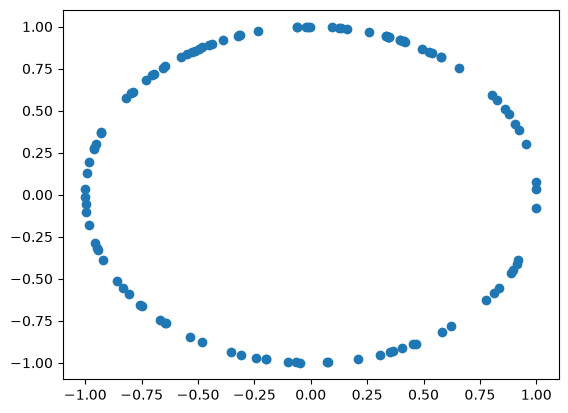

In [5]:
# `dir_` tensörünün 0. sütununu x, 1. sütununu y ekseni olarak
# serpiştirir. Neden: normalize edilmiş yön vektörlerinin gerçekten
# çember üzerinde olduğunu hızlıca kontrol etmek. Yarar: `norm` ile
# bölmenin ne yaptığı tek bakışta görünür; plt.scatter grafik nesnesi
# döndürüp metin çıktısı ürettiği için Jupyter ayrıca çizimi de gösterir.
plt.scatter(dir_[:,0],dir_[:,1])

## 2 · Tensor Kavramı

**Tensor**, PyTorch'un temel veri taşıyıcısı: çok boyutlu bir sayı dizisi + iki süper güç:

1. **GPU'da yaşayabilir** (hesap paralelleşir),
2. **Otomatik türev** alabilir (`autograd` — bu oturumun sonunda bir tadını göreceğiz).

Boyut sıralaması:

| Ad | Örnek | `shape` | Gerçek dünya |
|---|---|---|---|
| Skaler | `5.0` | `[ ]` | tek piksel değeri, sıcaklık |
| Vektör | `[5, 3, 8]` | `[3]` | bir pikselin RGB'si, bir kelime vektörü |
| Matris | 3×4 tablo | `[3, 4]` | gri tonlu görüntü |
| Tensor | küp | `[2, 3, 4]` | renkli görüntü `[H, W, 3]`, video `[B, H, W, 3]` |

### Arka plandaki matematik

Tensor, boyut (eksen) sayısıyla tanımlanır. Boyut hiyerarşisi:

$$\text{skaler (0 eksen)} \to \text{vektör (1 eksen)} \to \text{matris (2 eksen)} \to \text{tensor (N eksen)}$$

Bir tensorün **shape**'i her eksendeki eleman sayısıdır; toplam eleman sayısı shape'in çarpımıdır: $\text{numel} = s_1 \cdot s_2 \cdots s_k$. Mini sayısal örnek: shape $[3, 4]$ matriste $3 \times 4 = 12$ eleman vardır; shape $[2, 3, 4]$ üç boyutlu tensörde $2 \times 3 \times 4 = 24$.

> Bu blok için gerekli: sonraki tüm oturumlarda veri hep tensor olarak akacak (görüntü $[H, W, 3]$, batch $[B, H, W, 3]$); klip, bu hiyerarşiyi animasyonla yerleştirir.

In [6]:
# 2.1 — Boyut boyut tensor
# Tensor kavramını anlatan klibi notebook içine gömer (`embed=True`).
# Neden: boyut hiyerarşisini görsel kurmak. Yarar: hemen ardından gelen
# kod hücresindeki shape/ndim çıktılarını önceden tahmin edebilir hâle
# gelirsin.
Video("assets/03-tensor.mp4", width=1000, embed=True)

### Arka plandaki matematik

Klip'teki hiyerarşinin sayısal karşılığı bu hücrede: her tensor için `ndim` (eksen sayısı), `shape` (eksen uzunlukları) ve `numel` (eleman sayısı $= s_1 s_2 \cdots s_k$) tutarlıdır. Örnek: `arange(12)` değerleriyle kurulan $[3,4]$ matrisin ilk satırı $[0, 1, 2, 3]$, son satırı $[8, 9, 10, 11]$ olur.

In [7]:
# Tensor kütüphanesi; bu hücrenin tüm işi tensor kurmak.
import torch

# 0 eksenli tek sayı (shape []); hiyerarşinin en alt basamağı. Tek piksel
# değeri veya kayıp sayısı hep bu tiptedir.
skaler  = torch.tensor(5.0)
# 3 elemanlı 1 eksenli vektör (shape [3]); bir öznitelik satırını
# temsil eder.
vektor  = torch.tensor([5.0, 3.0, 8.0])
# 0–11 sayılarını üretip 3 × 4 matrise dizer. `arange` + `reshape`
# ikilisi ileride elle veri kurarken sürekli kullanılacak kalıptır;
# dtype=float32 derin öğrenmenin standart sayı tipidir.
matris  = torch.arange(12, dtype=torch.float32).reshape(3, 4)
# Aynı değerleri 3 eksenli (2 × 3 × 4) tensöre dizer; görüntü batch'leri
# tam böyle görünür ([B, H, W]).
tensor3 = torch.arange(24, dtype=torch.float32).reshape(2, 3, 4)

# Dört tensorü tek döngüde gezer; dört ayrı print yerine tek satır,
# karşılaştırma aynı tabloda.
for ad, t in [("skaler", skaler), ("vektör", vektor), ("matris", matris), ("tensor", tensor3)]:
    # Her tensorün kimlik kartını hizalı basar; shape–ndim–numel ilişkisini
    # gözle doğrular. f"{ad:8s}" gibi hizalama, okunabilir çıktının pratik
    # numarasıdır.
    print(f"{ad:8s} | shape={tuple(t.shape)!s:12s} | ndim={t.ndim} | eleman={t.numel()} | dtype={t.dtype}")

# Çıktı düzeni için boş satır ve başlık basar.
print()
print("matris:")
# Matrisi düz metin olarak gösterir; reshape(3, 4) değerlerinin nasıl
# dizerildiğini görürsün.
print(matris)

skaler   | shape=()           | ndim=0 | eleman=1 | dtype=torch.float32
vektör   | shape=(3,)         | ndim=1 | eleman=3 | dtype=torch.float32
matris   | shape=(3, 4)       | ndim=2 | eleman=12 | dtype=torch.float32
tensor   | shape=(2, 3, 4)    | ndim=3 | eleman=24 | dtype=torch.float32

matris:
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])


### Görüntü = tensor: kendi gözünle gör

Bir renkli görüntü, PyTorch'ta `[H, W, 3]` şeklinde bir tensördür — yükseklik × genişlik × renk kanalı.
Aşağıdaki hücre **sıfırdan sentetik bir görüntü üretir** (kamera yok, dosya yok), kanallarını ayırır ve kırpar.

### Arka plandaki matematik

Bir gri tonlu görüntü, bir fonksiyondur: $I(x, y)$ piksel satırı $y$, sütunu $x$ olan noktanın parlaklığını verir. Renkli görüntüde çıktı 3 sayılık vektördür: $I(x,y) \in [0,1]^3$ (R, G, B). PyTorch bunu shape $[H, W, 3]$ tensör olarak tutar.

Bu hücre koordinat ızgarasını **meshgrid** ile kurar: $x_{ij} = j/(W-1)$, $y_{ij} = i/(H-1)$ — yani her piksele 0–1 arası bir koordinat yazılır. Sonra her kanala basit bir doğrusal desen atanır: kırmızı kanal $1-x$ (soldan sağa azalır), yeşil $y$, mavi $x$.

**Dilimleme aritmetiği:** `img[16:112, 48:144]` → satır sayısı $112-16 = 96$, sütun $144-48 = 96$, kanal 3 kalır → shape $[96, 96, 3]$.

görüntü tensörü shape: (128, 192, 3) | dtype: torch.float32


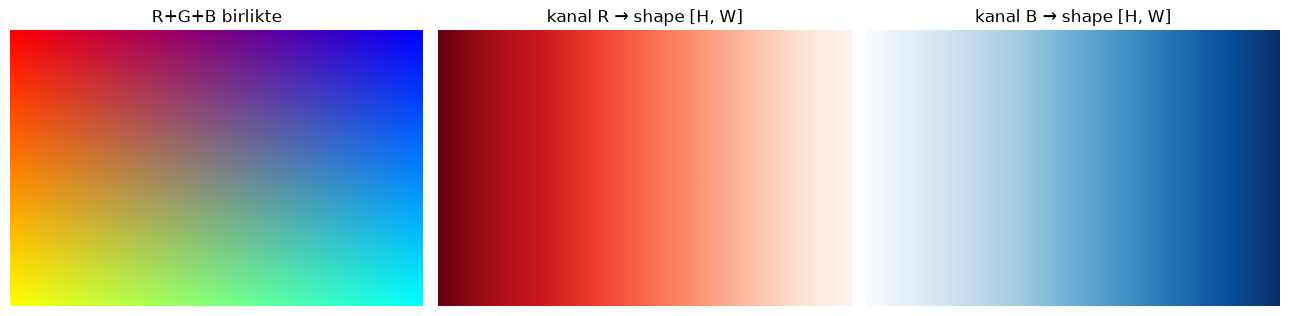

kırpık shape: (96, 96, 3)


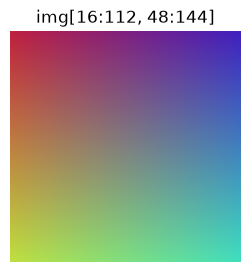

In [8]:
# torch: tensor kütüphanesi; matplotlib.pyplot: grafik kütüphanesi.
# Neden: sentetik görüntü üretip çizeceğiz.
import torch
import matplotlib.pyplot as plt

# Yükseklik ve genişlik sabitleri; boyutları tek yerde tutmak.
# Değiştirmek istersen tek satır.
H, W = 128, 192
# İki 1B ekseniden [H, W]'lik iki koordinat haritası üretir: her piksele
# 0–1 arası bir koordinat yazar. `linspace(0, 1, H)` 0 ile 1 arasında H
# eşit değer üretir. `indexing="ij"` satır-sütun sırasını garanti eder.
y_koord, x_koord = torch.meshgrid(
    torch.linspace(0, 1, H), torch.linspace(0, 1, W), indexing="ij"
)
# Siyah [128, 192, 3] görüntü tensörü; kanallarını tek tek dolduracağız.
# Görüntünün bellekteki gerçek hâli budur.
img = torch.zeros(H, W, 3)
# Kanallara koordinata bağlı desenler yazar; `...` "önceki tüm eksenleri
# olduğu gibi al" demektir. Hangi ekseni hangi kanalın tuttuğunu görsel
# olarak öğrenirsin.
img[..., 0] = 1 - x_koord   # kırmızı: soldan sağa azalır
img[..., 1] = y_koord       # yeşil: yukarıdan aşağıya artar
img[..., 2] = x_koord       # mavi: soldan sağa artar

# Görüntü tensörünün kimlik kartını basar; [H, W, 3] sözünün karşılığını
# sayılarla görürsün.
print("görüntü tensörü shape:", tuple(img.shape), "| dtype:", img.dtype)

# Yan yana üç grafik ekseni: tam görüntü, R kanalı, B kanalı.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
# 3 kanallı tensörü renkli görüntü olarak çizer; tensörü insan gözüne
# çevirir. "Görüntü = sayı dizisi" iddiasının kanıtı.
axes[0].imshow(img);            axes[0].set_title("R+G+B birlikte")
# Sadece 0. kanalı ([H, W]'lik matris) kırmızı tonlamalı çizer; tek
# kanalın da bir görüntü olduğunu gösterir. Kanal ayrımı CNN'lerde
# (oturum 4) temel olacak.
axes[1].imshow(img[..., 0], cmap="Reds");   axes[1].set_title("kanal R → shape [H, W]")
# Mavi kanalı çizer.
axes[2].imshow(img[..., 2], cmap="Blues");  axes[2].set_title("kanal B → shape [H, W]")
# Tüm eksenlerden sayı çerçevesini kaldırır; temiz görüntü görünümü.
for ax in axes: ax.axis("off")
# Boşlukları sıkıştırıp figürü ekrana basar.
plt.tight_layout(); plt.show()

# Dilimleme: bir bölgeyi kırpmak = tensor dilimlemek
# Tensor dilimleme ile merkez bölgeyi kopyasız seçer. Kırpma = dilimleme;
# veri hazırlığında crop işleminin ta kendisi. Dilim tensörü orijinal
# belleği paylaşır (kopya yok, hızlı).
kirpik = img[16:112, 48:144]
# [96, 96, 3] çıktısını basar; dilimleme aritmetiğini (112-16 ve 144-48)
# doğrular.
print("kırpık shape:", tuple(kirpik.shape))

# Kırpık için küçük tek eksen açar.
fig, ax = plt.subplots(figsize=(3, 3))
# Kırpmayı çizer, başlık olarak kullanılan dilim ifadesini yazar,
# çerçeveyi kapatır.
ax.imshow(kirpik); ax.set_title("img[16:112, 48:144]"); ax.axis("off")
# Figürü ekrana basar.
plt.show()

### Günlük hayatta kullanacağın üç operasyon

- **`reshape` / `view`** — aynı veri, yeni şekil (eleman sayısı korunur)
- **Broadcasting** — farklı şekillerin uyumlu biçimde birleşmesi (ör. `[3, 4] + [4]`)
- **`@` (matmul)** — matris çarpımı; derin ağın her katmanı budur

### Arka plandaki matematik

Üç temel kural:

1. **`reshape`**: şekil değişir, eleman sayısı korunur: $\text{numel} = s_1 \cdots s_k$ değişmez. $3 \times 4 = 12$ eleman, $2 \times 6 = 12$'ye tam bölünür — ama $2 \times 5 = 10$'a bölünemez.
2. **Broadcasting**: iki tensor şekil farkıyla toplanacaksa, eksenler **sondan başlayarak** hizalanır; her çift ya eşit ya da biri 1 olmalı. $(3,4) + (4,) \Rightarrow$ vektör sağa hizalanır, her satıra kopyalanır.
3. **Matris çarpımı**: $(AB)_{ij} = \sum_k A_{ik} B_{kj}$ — A'nın $i$. satırı ile B'nin $j$. sütununun iç çarpımı. Şekil kuralı: $(m, k) \cdot (k, n) \to (m, n)$; iç ekseni eşit olmalı.

**Elle hesap (2×2 · 2×2, tek hücreyi adım adım):**
$$A = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix},\quad B = \begin{pmatrix} 5 & 6 \\ 7 & 8 \end{pmatrix}$$
$$(AB)_{11} = 1\cdot5 + 2\cdot7 = 19,\quad (AB)_{12} = 1\cdot6 + 2\cdot8 = 22$$
$$(AB)_{21} = 3\cdot5 + 4\cdot7 = 43,\quad (AB)_{22} = 3\cdot6 + 4\cdot8 = 50$$
$$AB = \begin{pmatrix} 19 & 22 \\ 43 & 50 \end{pmatrix}$$

Kod hücresindeki $(3,4) @ (4,2) \to (3,2)$ çarpımı aynı kuralın daha geniş hâlidir: her sonuç hücresi 4 terimlik bir iç çarpımdır.

> Bu blok için gerekli: derin ağın her katmanı bir matris çarpımıdır ($y = Wx + b$); reshape ve broadcasting ise veri hazırlığında her gün karşılaşacağın iki kuraldır. Bu üçünü elle bilmek, shape hatalarını ezbere değil mantıkla çözmeni sağlar.

In [9]:
# Tensor kütüphanesi; üç operasyon da tensor üzerinde çalışır.
import torch

# 0–11 değerlerini 3 × 4 matrise dizer; üzerinde oynanacak standart
# örnek. Hücre 2.1'deki matrisle aynı olduğu için çıktılar
# karşılaştırılabilir.
matris = torch.arange(12, dtype=torch.float32).reshape(3, 4)
# 4 elemanlı vektör; matrisin sütun sayısıyla (4) uyuşan broadcast
# ortağı.
vektor = torch.tensor([10.0, 20.0, 30.0, 40.0])

# 1) reshape: 3x4 -> 2x6 (eleman sayısı 12 = 12)
# Aynı 12 değeri 2 × 6 şeklinde basar; değerlerin sırası korunur,
# satırlar yeniden bölünür.
print("reshape(2, 6):")
print(matris.reshape(2, 6))

# 2) broadcasting: (3,4) + (4,) -> satır satır eklenir
print()
# (3,4) matrise (4,) vektörü satır satır ekler: her satır [10, 20, 30, 40]
# artar. Normalize etme (x - ortalama gibi) işlemlerinin temelidir.
print("broadcasting  matris + vektör:")
print(matris + vektor)

# 3) matmul: (3,4) @ (4,2) -> (3,2)
# İsim kısaltması; kopya değil, aynı tensöre ikinci isim.
A = matris
# 0–7 değerlerini 4 × 2 matrise dizer; matmulun iç ekseni (4) A'nın
# sütun sayısıyla eşleşsin. Şekil kuralı (3,4) @ (4,2) -> (3,2)
# doğrulanır.
B = torch.arange(8, dtype=torch.float32).reshape(4, 2)
print()
# Çarpım öncesi ve sonrası şekilleri basar; (m,k)(k,n)->(m,n) kuralını
# çıktıda görürsün.
print(f"matmul: {tuple(A.shape)} @ {tuple(B.shape)} -> {tuple((A @ B).shape)}")
# Matris çarpımını hesaplayıp basar; `@` PyTorch'ta matmul operatörüdür.
# Derin ağdaki her nn.Linear arka planda tam bu işlemdir.
print(A @ B)

reshape(2, 6):
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10., 11.]])

broadcasting  matris + vektör:
tensor([[10., 21., 32., 43.],
        [14., 25., 36., 47.],
        [18., 29., 40., 51.]])

matmul: (3, 4) @ (4, 2) -> (3, 2)
tensor([[ 28.,  34.],
        [ 76.,  98.],
        [124., 162.]])


### Tadımlık: otomatik türev (`autograd`)

Derin öğrenmenin motoru: ağın milyonlarca parametresinin türevidini PyTorch **kendisi** hesaplar.
Küçük bir örnek: $y = 3x^2 + 2x + 1$ fonksiyonunun $x = 2$ noktasındaki türevi $\;dy/dx = 6x + 2 = 14$.

### Arka plandaki matematik

Türev, fonksiyonun bir noktadaki değişim hızıdır. Güç kuralı: $\frac{d}{dx}x^n = n x^{n-1}$; sabit ve katsayılar dışarı çıkar:

$$y = 3x^2 + 2x + 1 \;\Rightarrow\; \frac{dy}{dx} = 6x + 2 \;\Rightarrow\; \left.\frac{dy}{dx}\right|_{x=2} = 6\cdot2 + 2 = 14$$

**autograd bunu nasıl yapar?** Her işlem (çarpma, toplama, üs) hesap grafiğine kaydedilir; `backward()` çağrılınca **zincir kuralı** $\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$ grafiğin tersi yönde işletilir ve her ara değerin yerel türevi çarpılır. Sayısal örnek: $u = x^2$ ($u'(2)=4$), $y = 3u$ ($\partial y/\partial u = 3$) $\Rightarrow$ türev $3 \cdot 4 = 12$; artı $2x$ teriminin türevi $2$; toplam $14$.

> Bu blok için gerekli: sonraki oturumda gradyan inişi tam bu türevlere dayanacak — milyonlarca parametreli ağda elle türev yazmak imkânsızken autograd zincir kuralını otomatik işletir. Burada en küçük örneklerle mekaniği görüyorsun.

In [10]:
# Tensor + otomatik türev (autograd) motoru; bu hücrenin asıl konusu.
import torch

# Türev takibi istenen bir skaler tensor kurar; `requires_grad=True`
# "bu değişkenin türevini hesapla" rozetidir. Model parametreleri tam
# böyle yaratılır.
x = torch.tensor(2.0, requires_grad=True)
# Fonksiyonu değerlendirir; PyTorch her işlemi (çarpma, toplama, üs)
# hesap grafiğine kaydeder. Hem değer hem türev lazım; kod ile
# matematik birebir aynı okunur.
y = 3 * x**2 + 2 * x + 1

# Zincir kuralını grafiğin tersi yönde işletip x'e göre türevi hesaplar;
# tek çağrıyla tüm parametrelerin gradyanı dolar.
y.backward()          # türevi geriye doğru hesapla
# Fonksiyon değerini basar (y(2) = 3*4 + 4 + 1 = 17,0); `.item()` tek
# elemanlı tensörü Python sayısına çevirir.
print(f"y(x=2)      = {y.item():.1f}")
# Hesaplanan gradyanı (x.grad) beklenen analitik değerle yan yana basar;
# autograd'ın doğru çalıştığı sayıyla kanıtlanır. "Beklenen vs bulunan"
# kalıbı oturum 2'de gradyan doğrulamasında tekrar kullanılacak.
print(f"dy/dx(x=2)  = {x.grad.item():.1f}   # beklenen: 6*2 + 2 = 14")

y(x=2)      = 17.0
dy/dx(x=2)  = 14.0   # beklenen: 6*2 + 2 = 14


## Mini Quiz

1. Klasik ML ile derin öğrenmeyi ayıran **tek cümlelik** fark nedir?
2. `torch.zeros(32, 64, 64, 3)` tensörünün `shape`'i nedir ve muhtemelen neyi temsil eder?
3. Bir matrisin shape'i `[3, 4]`; eleman sayısı kaçtır? `reshape(2, 6)` yapılabilir mi, neden?
4. (3, 4) boyutlu bir matrise (4,) boyutlu bir vektör ekleyebilir miyiz? Bu işlem ne denir?

### Cevaplar

<details><summary>Açmak için tıkla</summary>

1. Klasik ML'de özniteliği **insan** tasarlar; derin öğrenmede özniteliği **ağ ham veriden öğrenir**.
2. `shape = [32, 64, 64, 3]` → 32 adet 64×64 renkli görüntü (mini-batch).
3. 12 eleman. Evet — 2×6 = 12 olduğundan eleman sayısı korunur.
4. Evet — broadcasting: (4,) vektörü satırlara otomatik "kopyalanır", sonuç (3, 4).

</details>

---

## Özet

- Derin öğrenme = **özniteliği de öğrenen** makine öğrenmesi.
- Bunu mümkün kılan üç güç: **büyük veri + GPU + öğrenilen temsil**.
- Tensor: skaler → vektör → matris → N boyut; `shape` / `ndim` / `dtype` üçlüsü her tensorün kimliğidir.
- Görüntü = `[H, W, 3]` tensor; eğitim = `[B, H, W, 3]`.

**Sonraki oturum:** Gradyan inişini sıfırdan kuruyoruz — `autograd` ile ilk yapay sinir ağımızı eğiteceğiz.

## Kaynakça

- PyTorch — Tensors: <https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html>
- 3Blue1Brown — Neural Networks (görsel seriler): <https://www.3blue1brown.com/topics/neural-networks>
- Goodfellow, Bengio, Courville — *Deep Learning*, Böl. 1–2 (ücretsiz): <https://www.deeplearningbook.org>

## Kodlama Soruları

Bu oturumun kodları üzerinden 4-5 kodlama görevi. Her görevi kendi başına çalışabilen bir hücrede dene; beklenen çıktı her soruda tanımlı.

### Soru 1 — Boyut manipülasyonu (reshape / permute)

`torch.arange(24)` değerleriyle shape'i $[2, 3, 4]$ olan bir tensor kur. Şunları yazdır:

- `ndim` ve `numel` değerleri (beklenen: 3 ve 24),
- `permute(0, 2, 1)` sonrası shape (beklenen: `[2, 4, 3]`),
- permute edilmiş tensorün yeniden `reshape(-1)` ile düzleştirilmiş ilk 6 değeri.

**Soru:** `reshape(2, 4, 3)` ile `permute(0, 2, 1)` aynı shape'i verir ama içerikleri farklıdır. Fark ne?

<details><summary>Çözüm fikri</summary>

```python
import torch
t = torch.arange(24).reshape(2, 3, 4)
print("ndim:", t.ndim, "| numel:", t.numel())
p = t.permute(0, 2, 1)          # eksen sırasını değiştirir: [2,4,3]
print("permute shape:", tuple(p.shape))
print("ilk 6:", t.reshape(-1)[:6])
print("permute sonrası ilk 6:", p.reshape(-1)[:6])
```

Beklenen: `ndim: 3 | numel: 24`, `permute shape: (2, 4, 3)`. `permute` **veriyi yeniden dizer** (eksenleri takas eder: $[i, k, j]$ pozisyonundaki değer $[i, j, k]$'den gelir), `reshape` ise **bellek sırasını koruyarak** yeniden böler — bu yüzden ilk 6 değer farklıdır. Çözüm fikri: `t` ile `p.reshape(-1)` çıktılarını yan yana basıp farkı gözle doğrula.
</details>

### Soru 2 — Matris çarpımı: elle vs torch

$A = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix}$ ve $B = \begin{pmatrix} 5 & 6 \\ 7 & 8 \end{pmatrix}$ için:

1. $(AB)_{11}$ hücresini **yalnızca skaler çarpma ve toplama** ile Python'da hesapla (döngü veya düz ifade).
2. `torch.tensor` ile $A$ ve $B$'yi kurup `A @ B` hesapla.
3. İki sonucun eşitliğini `torch.allclose` ile doğrula (beklenen çıktı: `True`).

<details><summary>Çözüm fikri</summary>

```python
import torch
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

elle_11 = A[0, 0] * B[0, 0] + A[0, 1] * B[1, 0]     # 1*5 + 2*7
print("elle (AB)_11 =", elle_11.item())             # beklenen: 19.0
print("torch A@B:")
print(A @ B)                                        # [[19, 22], [43, 50]]
print("eşit mi:", torch.allclose((A @ B)[0, 0], elle_11))
```

Çözüm fikri: `elle_11` ifadesindeki iki terimin tam olarak $(AB)_{11} = \sum_k A_{1k}B_{k1}$ formülüne karşılık geldiğini kontrol et; ardından dördüncü hücreyi de elle yazmak istersen $(AB)_{22} = 3\cdot6 + 4\cdot8 = 50$ ile kıyasla.
</details>

### Soru 3 — Broadcast kuralı testi

Aşağıdaki şekil çiftlerinin toplanabilirliğini dener ve sonuç shape'i yazdıran bir hücre kur: `(3,4)+(4,)`, `(3,4)+(3,)`, `(3,1)+(1,4)`, `(2,3,4)+(4,)`. Her denemeyi `try/except RuntimeError` ile sarmala; toplanamayan çiftlerde hatayı yakalayıp `"broadcast YOK"` yazdır.

**Beklenen çıktı:** 1., 3. ve 4. çift başarılı (sırasyla `(3,4)`, `(3,4)`, `(2,3,4)`), 2. çift başarısız.

<details><summary>Çözüm fikri</summary>

```python
import torch
denemeler = [((3, 4), (4,)), ((3, 4), (3,)), ((3, 1), (1, 4)), ((2, 3, 4), (4,))]
for s1, s2 in denemeler:
    try:
        sonuc = torch.zeros(s1) + torch.zeros(s2)
        print(s1, "+", s2, "->", tuple(sonuc.shape))
    except RuntimeError:
        print(s1, "+", s2, "-> broadcast YOK")
```

Çözüm fikri: kural — eksenler sondan hizalanır, her çift ya eşit ya da biri 1 olmalı. `(3,4)+(3,)`'te sondan 4 ile 3 çakışır; `(3,1)+(1,4)`'te 1'ler "kopyalanabilir" olduğundan sonuç $(3,4)$ olur.
</details>

### Soru 4 — Vektör normu: elle vs torch

$u = [3, 4]$ vektörü için: (a) $\|u\|_2 = \sqrt{u_1^2 + u_2^2}$'yi Python skaler ifadesiyle hesapla; (b) aynı değeri `u.norm()` ile hesapla; (c) `u / u.norm()` ile birim vektörü üretip normunun 1 olduğunu yazdır (beklenen: `5.0`, `5.0`, `1.0`).

<details><summary>Çözüm fikri</summary>

```python
import torch
u = torch.tensor([3.0, 4.0])
elle = (u[0]**2 + u[1]**2) ** 0.5
print("elle norm:", elle.item())          # beklenen: 5.0
print("torch norm:", u.norm().item())     # beklenen: 5.0
birim = u / u.norm()
print("birim vektör:", birim, "| normu:", birim.norm().item())  # norm 1.0
```

Çözüm fikri: bu, halka-problemi hücresindeki `dir_ / dir_.norm(...)` satırının iki satırlık özeti; birim vektörün normu 1 çünkü pay ve payda aynı sayı.
</details>

### Soru 5 — Görüntü dilimleme

`torch.arange(64, dtype=torch.float32).reshape(8, 8)` ile 8×8 bir "görüntü" kur:

- Merkezdeki $4\times4$ bölgeyi dilimle (`img[2:6, 2:6]`) ve shape'ini yazdır (beklenen: `torch.Size([4, 4])`).
- Bu bölgenin sol üst köşesindeki değeri yazdır (beklenen: 18.0 — kontrol et: satır 2, sütun 2 → $2\cdot8+2$).
- Dilimi `reshape(-1)` ile düzleştir; eleman sayısı kaç? (beklenen: 16)

<details><summary>Çözüm fikri</summary>

```python
import torch
img = torch.arange(64, dtype=torch.float32).reshape(8, 8)
kirpik = img[2:6, 2:6]
print("shape:", kirpik.shape)             # torch.Size([4, 4])
print("sol üst:", kirpik[0, 0].item())    # 18.0
print("eleman:", kirpik.reshape(-1).numel())  # 16
```

Çözüm fikri: `arange` değerleri satır-satır dizer; satır $i$, sütun $j$'deki değer $8i + j$'dir. Dilimleme aritmetiği: $6-2 = 4$ satır, $6-2 = 4$ sütun; eleman sayısı korunur.
</details>
